# 🍷 ElasticNet Wine Quality Experiment with MLflow & Ngrok

This notebook runs ElasticNet regression experiments on the **Red Wine Quality** dataset.  
It tracks metrics, parameters, and models using **MLflow**, and exposes the MLflow UI via **pyngrok**.

---
### Workflow:
1. Install dependencies
2. Load & explore the dataset
3. Define `train_model(alpha, l1_ratio)` training module
4. Run multiple experiments
5. Launch MLflow UI via ngrok tunnel


## 📦 Cell 1 — Install Dependencies

In [ ]:
# Install all required libraries
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn pyngrok --quiet
print("✅ All packages installed successfully!")

## 📚 Cell 2 — Imports

In [1]:
import os
import warnings
import subprocess
import threading
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.pipeline import Pipeline

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature


warnings.filterwarnings('ignore')
print("✅ All imports successful!")
print(f"MLflow version: {mlflow.__version__}")

✅ All imports successful!
MLflow version: 3.11.1


## 🍷 Cell 3 — Load Wine Quality Dataset

In [2]:
# Load the Red Wine Quality dataset

try:
    df = pd.read_csv(r"D:\Desktop\Data_Science\MLOPs\data\winequality-red.csv")
    print(f"✅ Dataset loaded from URL — shape: {df.shape}")
except Exception:
    # Fallback: use sklearn's built-in fetch or local generation
    print("⚠️  Could not fetch from URL. Generating synthetic wine data...")
    from sklearn.datasets import make_regression
    X_syn, y_syn = make_regression(n_samples=1599, n_features=11, noise=0.5, random_state=42)
    cols = [
        'fixed acidity','volatile acidity','citric acid','residual sugar',
        'chlorides','free sulfur dioxide','total sulfur dioxide','density',
        'pH','sulphates','alcohol'
    ]
    df = pd.DataFrame(X_syn, columns=cols)
    df['quality'] = np.clip(np.round(y_syn / y_syn.std() * 1.5 + 5.5), 3, 8).astype(int)
    print(f"✅ Synthetic dataset created — shape: {df.shape}")

df.head()

✅ Dataset loaded from URL — shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 🔍 Cell 4 — Exploratory Data Analysis

In [3]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape     : {df.shape}")
print(f"Columns   : {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget distribution:")
print(df['quality'].value_counts().sort_index())

DATASET OVERVIEW
Shape     : (1599, 12)
Columns   : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Target distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


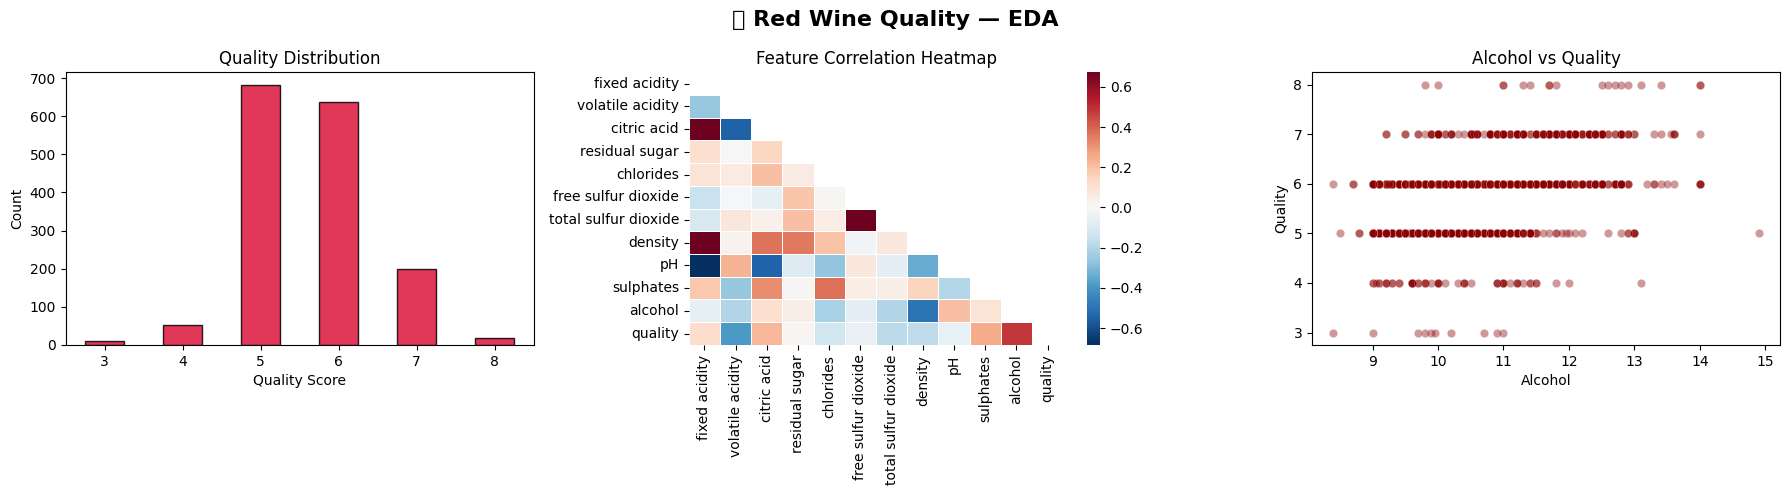

✅ EDA plots saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("🍷 Red Wine Quality — EDA", fontsize=16, fontweight='bold')

# 1. Quality distribution
df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='crimson', edgecolor='black', alpha=0.85
)
axes[0].set_title("Quality Distribution")
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# 2. Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[1], cmap='RdBu_r',
    center=0, annot=False, linewidths=0.5
)
axes[1].set_title("Feature Correlation Heatmap")

# 3. Alcohol vs Quality
axes[2].scatter(
    df['alcohol'], df['quality'],
    alpha=0.4, color='darkred', edgecolors='white', linewidths=0.3
)
axes[2].set_title("Alcohol vs Quality")
axes[2].set_xlabel("Alcohol")
axes[2].set_ylabel("Quality")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved.")

## ✂️ Cell 5 — Prepare Train / Test Split

In [5]:
# Features and target
TARGET = "quality"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Features         : {FEATURES}")

Training samples : 1279
Testing  samples : 320
Features         : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 🧪 Cell 6 — Setup MLflow Experiment

In [ ]:
# Set tracking URI (local by default)
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "ElasticNet_WineQuality_Red"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Create or get experiment
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    print(f"✅ Created new experiment: '{EXPERIMENT_NAME}' (id={experiment_id})")
else:
    experiment_id = experiment.experiment_id
    print(f"✅ Using existing experiment: '{EXPERIMENT_NAME}' (id={experiment_id})")

mlflow.set_experiment(EXPERIMENT_NAME)

## 🏋️ Cell 7 — Define `train_model` Module

In [ ]:
def eval_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute regression evaluation metrics.

    Parameters
    ----------
    y_true : array-like — ground truth values
    y_pred : array-like — predicted values

    Returns
    -------
    dict with rmse, mae, r2
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}


def train_model(
    alpha: float,
    l1_ratio: float,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    feature_names: list,
    run_name: str = None,
    max_iter: int = 1000,
    random_state: int = 42
) -> dict:
    """
    Train an ElasticNet model and log everything to MLflow.

    Parameters
    ----------
    alpha        : Regularization strength (λ).
    l1_ratio     : Mix ratio between L1 and L2 penalty.
                   0 → pure Ridge, 1 → pure Lasso.
    X_train / X_test  : Feature arrays.
    y_train / y_test  : Target arrays.
    feature_names     : Column names for the model signature.
    run_name          : Custom MLflow run name (optional).
    max_iter          : Max iterations for solver convergence.
    random_state      : Reproducibility seed.

    Returns
    -------
    dict with keys: run_id, params, metrics, model
    """
    if run_name is None:
        run_name = f"alpha={alpha}_l1_ratio={l1_ratio}"

    with mlflow.start_run(run_name=run_name) as run:

        # ── 1. Build Pipeline: Scaler + ElasticNet ──────────────────────
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                max_iter=max_iter,
                random_state=random_state
            ))
        ])

        # ── 2. Train ─────────────────────────────────────────────────────
        pipeline.fit(X_train, y_train)

        # ── 3. Predict ───────────────────────────────────────────────────
        y_train_pred = pipeline.predict(X_train)
        y_test_pred  = pipeline.predict(X_test)

        # ── 4. Compute Metrics ───────────────────────────────────────────
        train_metrics = eval_metrics(y_train, y_train_pred)
        test_metrics  = eval_metrics(y_test,  y_test_pred)

        # ── 5. Collect Params ────────────────────────────────────────────
        params = {
            "alpha"        : alpha,
            "l1_ratio"     : l1_ratio,
            "max_iter"     : max_iter,
            "random_state" : random_state,
            "scaler"       : "StandardScaler"
        }

        # ── 6. Log Params ────────────────────────────────────────────────
        mlflow.log_params(params)

        # ── 7. Log Metrics ───────────────────────────────────────────────
        mlflow.log_metrics({
            "train_rmse" : train_metrics["rmse"],
            "train_mae"  : train_metrics["mae"],
            "train_r2"   : train_metrics["r2"],
            "test_rmse"  : test_metrics["rmse"],
            "test_mae"   : test_metrics["mae"],
            "test_r2"    : test_metrics["r2"],
        })

        # ── 8. Log Model with Signature ──────────────────────────────────
        X_sample = pd.DataFrame(X_train[:5], columns=feature_names)
        signature = infer_signature(X_sample, pipeline.predict(X_train[:5]))

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path="elasticnet_model",
            signature=signature,
            input_example=X_sample,
            registered_model_name=None  # set a name to register in Model Registry
        )

        # ── 9. Log ElasticNet Coefficients as artifact ───────────────────
        coef_df = pd.DataFrame({
            "feature"     : feature_names,
            "coefficient" : pipeline.named_steps["model"].coef_
        }).sort_values("coefficient", key=abs, ascending=False)

        coef_path = f"coef_alpha{alpha}_l1{l1_ratio}.csv"
        coef_df.to_csv(coef_path, index=False)
        mlflow.log_artifact(coef_path)
        os.remove(coef_path)

        run_id = run.info.run_id

    # ── 10. Console Summary ───────────────────────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  Run     : {run_name}")
    print(f"  Run ID  : {run_id}")
    print(f"  Params  : alpha={alpha}, l1_ratio={l1_ratio}")
    print(f"  Train   → RMSE={train_metrics['rmse']:.4f}  "
          f"MAE={train_metrics['mae']:.4f}  R²={train_metrics['r2']:.4f}")
    print(f"  Test    → RMSE={test_metrics['rmse']:.4f}  "
          f"MAE={test_metrics['mae']:.4f}  R²={test_metrics['r2']:.4f}")
    print(f"{'─'*55}")

    return {
        "run_id"  : run_id,
        "params"  : params,
        "metrics" : {"train": train_metrics, "test": test_metrics},
        "model"   : pipeline
    }


print("✅ train_model() and eval_metrics() defined successfully!")

## 🚀 Cell 8 — Start MLflow Tracking Server

In [ ]:
# Start mlflow server in background
mlflow_process = subprocess.Popen(
    ["mlflow", "ui", "--host", "127.0.0.1", "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)   # give server a moment to start
print(f"✅ MLflow UI started at http://127.0.0.1:5000  (PID={mlflow_process.pid})")

## 🔬 Cell 9 — Run Multiple Experiments

In [ ]:
# ── Define hyperparameter grid ─────────────────────────────────────────────
experiment_grid = [
    # (alpha, l1_ratio)
    (0.01,  0.1),   # Near Ridge
    (0.01,  0.5),   # Balanced
    (0.01,  0.9),   # Near Lasso
    (0.1,   0.1),
    (0.1,   0.5),
    (0.1,   0.9),
    (0.5,   0.1),
    (0.5,   0.5),
    (0.5,   0.9),
    (1.0,   0.1),
    (1.0,   0.5),
    (1.0,   0.9),
]

# ── Run all experiments ────────────────────────────────────────────────────
all_results = []

print(f"Running {len(experiment_grid)} experiments...\n")

for i, (alpha, l1_ratio) in enumerate(experiment_grid, 1):
    print(f"[{i:02d}/{len(experiment_grid)}] alpha={alpha}, l1_ratio={l1_ratio}")
    result = train_model(
        alpha=alpha,
        l1_ratio=l1_ratio,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=FEATURES
    )
    all_results.append(result)

print(f"\n✅ All {len(experiment_grid)} experiments completed!")

## 📊 Cell 10 — Compare Results & Find Best Run

In [ ]:
# Build a summary DataFrame
rows = []
for r in all_results:
    rows.append({
        "run_id"     : r["run_id"][:8],
        "alpha"      : r["params"]["alpha"],
        "l1_ratio"   : r["params"]["l1_ratio"],
        "train_rmse" : r["metrics"]["train"]["rmse"],
        "test_rmse"  : r["metrics"]["test"]["rmse"],
        "train_mae"  : r["metrics"]["train"]["mae"],
        "test_mae"   : r["metrics"]["test"]["mae"],
        "train_r2"   : r["metrics"]["train"]["r2"],
        "test_r2"    : r["metrics"]["test"]["r2"],
    })

results_df = pd.DataFrame(rows).sort_values("test_rmse")

print("\n🏆 Experiment Results (sorted by test RMSE):")
display(results_df.style
    .background_gradient(subset=["test_rmse","test_mae"], cmap="RdYlGn_r")
    .background_gradient(subset=["test_r2"], cmap="RdYlGn")
    .format({
        "train_rmse": "{:.4f}", "test_rmse": "{:.4f}",
        "train_mae" : "{:.4f}", "test_mae" : "{:.4f}",
        "train_r2"  : "{:.4f}", "test_r2"  : "{:.4f}"
    })
)

best = results_df.iloc[0]
print(f"\n🥇 Best run → alpha={best['alpha']}, l1_ratio={best['l1_ratio']}")
print(f"   Test RMSE: {best['test_rmse']:.4f} | R²: {best['test_r2']:.4f}")

## 📈 Cell 11 — Visualize Experiment Results

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("ElasticNet Experiment Comparison", fontsize=16, fontweight='bold')

# Helper: labels
labels = [f"α={r['alpha']}\nλ={r['l1_ratio']}" for r in rows]
x = np.arange(len(labels))
width = 0.35

# 1. RMSE comparison
axes[0].bar(x - width/2, results_df.sort_index()["train_rmse"], width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, results_df.sort_index()["test_rmse"],  width, label='Test',  color='crimson',   alpha=0.8)
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"α={r['params']['alpha']}\nλ={r['params']['l1_ratio']}" for r in all_results],
    fontsize=7
)
axes[0].legend()
axes[0].set_ylabel("RMSE")

# 2. R² comparison
axes[1].bar(x - width/2, results_df.sort_index()["train_r2"], width, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, results_df.sort_index()["test_r2"],  width, label='Test',  color='crimson',   alpha=0.8)
axes[1].set_title("R² Score (higher is better)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"α={r['params']['alpha']}\nλ={r['params']['l1_ratio']}" for r in all_results],
    fontsize=7
)
axes[1].legend()
axes[1].set_ylabel("R²")

# 3. Heatmap of Test RMSE over alpha x l1_ratio
pivot = results_df.pivot_table(
    index='alpha', columns='l1_ratio', values='test_rmse', aggfunc='mean'
)
sns.heatmap(
    pivot, ax=axes[2], annot=True, fmt=".4f",
    cmap="RdYlGn_r", linewidths=0.5
)
axes[2].set_title("Test RMSE Heatmap\n(alpha × l1_ratio)")

plt.tight_layout()
plt.savefig("experiment_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plots saved.")

## 🔭 Cell 12 — Inspect Best Model Coefficients

In [ ]:
# Retrieve the best model
best_idx = results_df.index[0]
best_result = all_results[best_idx]
best_model  = best_result["model"]

coef_series = pd.Series(
    best_model.named_steps["model"].coef_,
    index=FEATURES
).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_series]
coef_series.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    f"Best Model Coefficients\n"
    f"(alpha={best_result['params']['alpha']}, l1_ratio={best_result['params']['l1_ratio']})",
    fontsize=13
)
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("best_model_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Coefficient plot saved.")

## 🌐 Cell 13 — Launch Ngrok Tunnel to MLflow UI

> **Replace** `YOUR_NGROK_AUTH_TOKEN` below with your actual token from https://dashboard.ngrok.com/get-started/your-authtoken

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  ⚠️  REPLACE THIS with your actual token from ngrok dashboard
#  https://dashboard.ngrok.com/get-started/your-authtoken
# ─────────────────────────────────────────────────────────────────
NGROK_AUTH_TOKEN = "YOUR_NGROK_AUTH_TOKEN"
MLFLOW_PORT     = 5000

# Set auth token
conf.get_default().auth_token = NGROK_AUTH_TOKEN
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Kill any existing tunnels
ngrok.kill()
time.sleep(1)

# Open tunnel
tunnel = ngrok.connect(MLFLOW_PORT, "http")
public_url = tunnel.public_url

print("=" * 60)
print("🌐  MLFLOW UI IS LIVE AT:")
print(f"    {public_url}")
print("=" * 60)
print(f"\n  Local  → http://127.0.0.1:{MLFLOW_PORT}")
print(f"  Public → {public_url}")
print("\n  Open the public URL in any browser.")
print("  Share it with teammates — valid while this cell is running.")

## 🔍 Cell 14 — Query MLflow Programmatically

In [ ]:
# Fetch all runs from MLflow tracking server
client = mlflow.tracking.MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

runs = client.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.test_rmse ASC"]
)

print(f"📋 Total logged runs: {len(runs)}")
print("\nTop 5 runs by Test RMSE:")
print(f"{'Run Name':<40} {'alpha':>6} {'l1_ratio':>9} {'test_rmse':>10} {'test_r2':>9}")
print("-" * 78)

for run in runs[:5]:
    name    = run.data.tags.get("mlflow.runName", "N/A")
    alpha   = run.data.params.get("alpha", "?")
    l1r     = run.data.params.get("l1_ratio", "?")
    t_rmse  = run.data.metrics.get("test_rmse", float("nan"))
    t_r2    = run.data.metrics.get("test_r2",   float("nan"))
    print(f"{name:<40} {alpha:>6} {l1r:>9} {t_rmse:>10.4f} {t_r2:>9.4f}")

## 🗑️ Cell 15 — Cleanup (Optional)

In [ ]:
# Uncomment to close ngrok tunnel and stop MLflow server

# ngrok.disconnect(tunnel.public_url)
# ngrok.kill()
# mlflow_process.terminate()
# print("✅ Ngrok tunnel closed and MLflow server stopped.")

---
## 📝 Summary

| Step | What Happens |
|---|---|
| **Load Data** | Red Wine Quality dataset (1599 samples, 11 features) |
| **Split** | 80% train / 20% test, `random_state=42` |
| **`train_model()`** | Builds `StandardScaler → ElasticNet` pipeline, logs params, metrics & model to MLflow |
| **Grid** | 12 combos of `alpha ∈ {0.01, 0.1, 0.5, 1.0}` × `l1_ratio ∈ {0.1, 0.5, 0.9}` |
| **MLflow** | Tracks every run; artifacts include model, signature, coefficients CSV |
| **Ngrok** | Exposes MLflow UI at a public HTTPS URL via `pyngrok` |

### Key Hyperparameters
- **alpha** — overall regularization strength. Higher → simpler model.
- **l1_ratio** — blend of Lasso (L1) and Ridge (L2).  
  - `l1_ratio=0` → pure Ridge  
  - `l1_ratio=1` → pure Lasso  
  - `0 < l1_ratio < 1` → ElasticNet
